In [30]:
# ==============================================================
# Example usage of trained Neural Networks
# Author: Elena González Prieto
# ==============================================================

import sys
import torch
import numpy as np
sys.path.insert(0, './classification/NN/')
sys.path.insert(0, './regression/NN/')
from NN_classification import NeuralNetwork as ClassificationNeuralNetwork
from NN_regression import NeuralNetwork as RegressionNeuralNetwork
import torch.nn.functional as F
from sklearn.metrics import balanced_accuracy_score, accuracy_score



In [3]:
# --------------------------------------------------------------
# Classification Model
# --------------------------------------------------------------

classification_model = ClassificationNeuralNetwork()

# Load the saved checkpoint for the classification model
classification_checkpoint = torch.load(
    "./classification/best_models/model_1018_ua7nca53.pt",  # replace with your file path
    map_location=torch.device("cpu")  # load on CPU for demonstration
)

# Load model weights
classification_model.load_state_dict(classification_checkpoint["model_state_dict"])

# Load normalization statistics (mean and std used during training)
input_mean = classification_checkpoint["train_mean"]
input_std = classification_checkpoint["train_std"]


# --------------------------------------------------------------
# Regression Model
# --------------------------------------------------------------

regression_model = RegressionNeuralNetwork()

# Load the saved checkpoint for the regression model
regression_checkpoint = torch.load(
    "./regression/best_models/model_1024_ggu76mfw.pt",
    map_location=torch.device("cpu")
)

# Load model weights
regression_model.load_state_dict(regression_checkpoint["model_state_dict"])


/tmp/ipykernel_2200324/1433848801.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  classification_checkpoint = torch.load(
/tmp/ipykernel_2200324/1433848801.py:28: Future

<All keys matched successfully>

In [35]:

# Data needs to be pre-processed in the exact way that the model was trained on. Input data should have the format 
# 0: log10(Age[Gyr] + 0.001) 1:log10(Rp[Rsun]+1) 2:log10(Vinf[km/s]) 3:ln(Mass1[MSUN]) 4:ln(Mass2[Msun])

# --------------------------------------------------------------
# Example input data
# --------------------------------------------------------------

# Example: say I have two 1 Msun stars, of age 5 Gyr, colliding at 100 km/s with periapsis of 0.5 Rsun: 
#--- Create the dataset ---# 

# 0:Met[Zsun],1:Age[Gyr],2:Rp[Rsun],3:Vinf[km/s],4:Mass1_i[MSUN],5:Mass2_i[Msun],6:R1[Rsun],7:R2[Rsun],8:Label,9:Mass1_f[MSUN],10:Mass2_f[MSUN],11:Sigma
data_dir = '/projects/b1095/SPH_ML_grid/starsmasher/0.01Zsun/collisions/off_the_grid/ood_data_n10k_splot22f_20251103.csv'

data_loaded  = np.loadtxt(data_dir, delimiter=',', dtype=float, skiprows = 1)

# Selecting only specific columns:
data = data_loaded[:, [1, 2, 3, 4, 5, 8]]
initial_masses = data_loaded[:, [4, 5]]
final_masses = data_loaded[:, [9, 10]]

# Re-assing final masses for merger cases to be all in mass1, otherwise there's a lot of confusion
merger_mask = data_loaded[:, 8] == 1
swap_rows = merger_mask & (final_masses[:, 0] == 0) & (final_masses[:, 1] > 0)
final_masses[swap_rows, 0], final_masses[swap_rows, 1] = (final_masses[swap_rows, 1], final_masses[swap_rows, 0])

# Use labels to startify the splits
labels = data[:,-1].astype(np.int64).copy()
labels[labels < 0] = 3 #replace locally the meaning of label -1

# Now create the regression dataset as [M1,f/Mtot,i , M2,f / Mtot,i, Mejec,f / Mtot,i]
y_data_reg = np.array([final_masses[:,0] / (initial_masses[:,0] + initial_masses[:,1]) , final_masses[:,1] / (initial_masses[:,0] + initial_masses[:,1]), ((initial_masses[:,0] + initial_masses[:,1]) - (final_masses[:,0] + final_masses[:,1]))/ (initial_masses[:,0] + initial_masses[:,1])] ).T

#Feature transform: log the x-data
x_data = data[:, :-1].copy()
x_data[:, 0] = np.log10(data[:, 0] + 0.001) # log ages
x_data[:, 1] = np.log10(data[:, 1] + 1) # log rp
x_data[:, 2] = np.log10(data[:, 2]) # log vinfs
x_data[:, 3] = np.log(data[:, 3])   # ln M1,i
x_data[:, 4] = np.log(data[:, 4])   # ln M2,i

# Record the initial masses to transform regression outputs
initial_masses = np.exp(x_data[:,3]) + np.exp(x_data[:,4])

# --------------------------------------------------------------
# Normalization
# --------------------------------------------------------------

# Subtract the mean and divide by standard deviation computed on the training set.
# This ensures the new input data has the same scaling as the data the model was trained on.
normalized_data = (x_data - input_mean) / input_std

print(np.shape(normalized_data))

# Convert to torch tensor and add batch dimension
X = torch.tensor(normalized_data, dtype=torch.float32)

print(X.shape)



(350, 5)
torch.Size([350, 5])


In [32]:
# --------------------------------------------------------------
# Make Predictions - Classification 
# --------------------------------------------------------------

# Classification labels include: 
# 0: mutual destruction, no stars left 
# 1: merger, one star left 
# 2: fly-by, two stars left
# 3: stripped star, 1 star left

classsification_pred = classification_model(X)
predicted_class = torch.argmax(classsification_pred, dim=1).tolist()

accuracy = accuracy_score(labels, predicted_class)
balanced_acc = balanced_accuracy_score(labels, predicted_class)

print(f"Balanced accuracy: {balanced_acc * 100} %")
print(f"Accuracy: {accuracy* 100} %")


Balanced accuracy: 86.07625482625483 %
Accuracy: 97.14285714285714 %


In [46]:
# --------------------------------------------------------------
# Make Predictions - Regression 
# --------------------------------------------------------------

# Regression quantities include (shape = [1, 3]): 
# M1,final [Msun] / Mtot,initial [Msun] (Note: you need to multiply by the initial mass of the system to recover the final mass in units of Msun)
# M2,final [Msun] / Mtot,initial [Msun] (Note: you need to multiply by the initial mass of the system to recover the final mass in units of Msun)
# Mejec,final [Msun] / Mtot,initial [Msun] (Here Mejec is the unbound mass)

regression_pred      = regression_model(X)
predicted_values = np.array(regression_pred.tolist())  # Converts tensor to a list

# Transform true labels 
true_mass1 = (y_data_reg[:,0]) * initial_masses 
true_mass2 = (y_data_reg[:,1]) * initial_masses

#-- Error metric 2: Absolute Errors in Mass 1 
predicted_mass1 = predicted_values[:,0] * initial_masses
predicted_mass2 = predicted_values[:,1] * initial_masses

median_abs_error_m1 = np.median(np.abs(predicted_mass1 - true_mass1)) 
median_abs_error_m2 = np.median(np.abs(predicted_mass2 - true_mass2)) 

print(f"Median Absolute Error in Mass 1: {median_abs_error_m1} Msun")
print(f"Median Absolute Error in Mass 2: {median_abs_error_m2} Msun")


#-- Error metric 3: Relative errors for cases where at least one star survives
median_rel_error_m1 = np.median(np.abs(predicted_mass1[true_mass1 != 0.] - true_mass1[true_mass1 != 0. ])/ true_mass1[true_mass1 != 0.])
median_rel_error_m2 = np.median(np.abs(predicted_mass2[true_mass2 != 0.] - true_mass2[true_mass2 != 0. ])/ true_mass2[true_mass2 != 0.])


print(f"Median Relative Error in Mass 1: {median_rel_error_m1 * 100} %")
print(f"Median Relative Error in Mass 2: {median_rel_error_m2 * 100} %")

Median Absolute Error in Mass 1: 0.024646462077141162 Msun
Median Absolute Error in Mass 2: 0.00011035378646861993 Msun
Median Relative Error in Mass 1: 0.6327770557749643 %
Median Absolute Error in Mass 2: 1.3255482243971666 %


(array([196.,   3.,  10.,  15.,  91.,   1.,   1.,   1.,   6.,  26.]),
 array([0.       , 0.4937858, 0.9875716, 1.4813574, 1.9751432, 2.468929 ,
        2.9627148, 3.4565006, 3.9502864, 4.4440722, 4.937858 ]),
 <BarContainer object of 10 artists>)

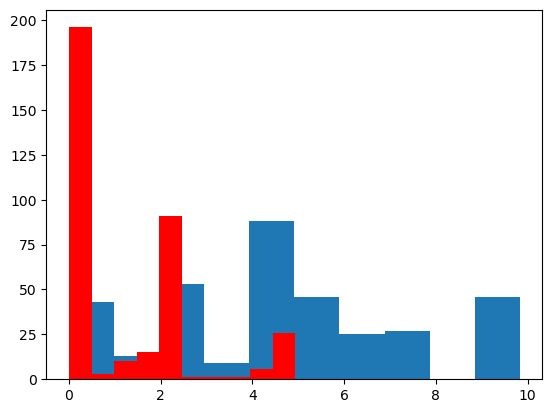

In [48]:
import matplotlib.pyplot as plt
plt.hist(true_mass1)
plt.hist(true_mass2, color = 'red')

At the same speed, age and masses:

rp - 200 Rsun
Predicted class: 2
Predicted Star 1 final mass in [MSUN]: 1.2899999618530273
Predicted Star 2 final mass in [MSUN]: 0.7099999785423279

rp - 20 Rsun, 
Predicted class: 2
Predicted Star 1 final mass in [MSUN]: 1.149999976158142
Predicted Star 2 final mass in [MSUN]: 0.8500000238418579

rp 2 Rsun 
Predicted class: 2
Predicted Star 1 final mass in [MSUN]: 1.0
Predicted Star 2 final mass in [MSUN]: 1.0

